# Machine Learning Final Project
**Logan Dawes** - CS4783

The goal of this project is to develop a machine learning model for both classification and prediction tasks. The model will be designed to automatically infer missing ingredient lists and nutrient information for a given food item. This enables it to perform ingredient classification as well as nutrient estimation

In [1]:
# Import data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
from tqdm import tqdm

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

In [2]:
# Load datatypes for final_food_data
with open('final_food_data_dtypes.json', 'r') as f:
    final_food_data_dtypes = json.load(f)

# Load processed dataset
food_data = pd.read_csv('final_food_data.csv', dtype=final_food_data_dtypes)

In [3]:
# Nutrient columns: all columns containing 'amount', excluding logs and package weight
nutrient_cols = [col for col in food_data.columns if ('amount' in col and not col.endswith('_log') and col != 'package_weight_amount')]
# Filter out nutrient columns with >90% zeros
nutrient_cols = [col for col in nutrient_cols if (food_data[col] == 0).mean() <= 0.9]
print(f'Nutrient columns selected ({len(nutrient_cols)}): {nutrient_cols}')

# Ingredient one-hot columns: all columns starting with 'ingredient_oh_'
ingredient_oh_cols = [col for col in food_data.columns if col.startswith('ingredient_oh_')]
# Filter out ingredient one-hot columns with >90% zeros
ingredient_oh_cols = [col for col in ingredient_oh_cols if (food_data[col] == 0).mean() <= 0.9]
print(f'Ingredient one-hot columns selected ({len(ingredient_oh_cols)}): {ingredient_oh_cols[:10]} ...')

# Feature columns: all columns except nutrient columns and dropped ingredient columns
exclude_cols = set(nutrient_cols)
exclude_cols.update(set(ingredient_oh_cols))
feature_cols = [col for col in food_data.columns if col not in exclude_cols]
print(f'Feature columns selected ({len(feature_cols)}): {feature_cols[:10]} ...')

Nutrient columns selected (15): ['Calcium, Ca amount', 'Carbohydrate, by difference amount', 'Cholesterol amount', 'Energy amount', 'Fatty acids, total saturated amount', 'Fiber, total dietary amount', 'Iron, Fe amount', 'Potassium, K amount', 'Protein amount', 'Sodium, Na amount', 'Sugars, added amount', 'Total Sugars amount', 'Total lipid (fat) amount', 'Vitamin A, IU amount', 'Vitamin C, total ascorbic acid amount']
Ingredient one-hot columns selected (8): ['ingredient_oh_salt', 'ingredient_oh_sugar', 'ingredient_oh_water', 'ingredient_oh_citricAcid', 'ingredient_oh_cornSyrup', 'ingredient_oh_naturalFlavor', 'ingredient_oh_soyLecithin', 'ingredient_oh_seaSalt'] ...
Feature columns selected (304): ['serving_size', 'Acetic acid amount', 'Alanine amount', 'Alcohol, ethyl amount', 'Arginine amount', 'Ash amount', 'Aspartic acid amount', 'Beta-glucans amount', 'Biotin amount', 'Caffeine amount'] ...


In [ ]:
# Prepare X and y
X = food_data[feature_cols].values
y = food_data[nutrient_cols].values

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Fit Random Forest model for multi-output regression
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test)

In [6]:
# Evaluate Random Forest benchmark
rmses_rf = [np.sqrt(mean_squared_error(y_test[:, i], y_pred_rf[:, i])) for i in range(len(nutrient_cols))]
r2s_rf = [r2_score(y_test[:, i], y_pred_rf[:, i]) for i in range(len(nutrient_cols))]
residuals_rf = y_test - y_pred_rf

print('Random Forest RMSEs:')
for col, rmse in zip(nutrient_cols, rmses_rf):
    print(f'RMSE for {col}: {rmse:.4f}')

print('\nRandom Forest R squared:')
for col, r2 in zip(nutrient_cols, r2s_rf):
    print(f'R squared for {col}: {r2:.4f}')

print('\nRandom Forest Residuals shape:', residuals_rf.shape)

Random Forest RMSEs:
RMSE for Calcium, Ca amount: 1.0452
RMSE for Carbohydrate, by difference amount: 22.2428
RMSE for Cholesterol amount: 0.0196
RMSE for Energy amount: 0.1918
RMSE for Fatty acids, total saturated amount: 4.7528
RMSE for Fiber, total dietary amount: 5.9136
RMSE for Iron, Fe amount: 0.1006
RMSE for Potassium, K amount: 0.0379
RMSE for Protein amount: 6.1799
RMSE for Sodium, Na amount: 0.0964
RMSE for Sugars, added amount: 7.0339
RMSE for Total Sugars amount: 15.0389
RMSE for Total lipid (fat) amount: 7.7904
RMSE for Vitamin A, IU amount: 0.0508
RMSE for Vitamin C, total ascorbic acid amount: 0.0329

Random Forest R squared:
R squared for Calcium, Ca amount: 0.8371
R squared for Carbohydrate, by difference amount: 0.7850
R squared for Cholesterol amount: 0.9957
R squared for Energy amount: 0.5926
R squared for Fatty acids, total saturated amount: 0.6952
R squared for Fiber, total dietary amount: 0.2336
R squared for Iron, Fe amount: 0.8862
R squared for Potassium, K amo

In [7]:
print('Random Forest RMSE Summary:')
print(f'Mean RMSE: {np.mean(rmses_rf):.4f}')
print(f'Median RMSE: {np.median(rmses_rf):.4f}')
print(f'Min RMSE: {np.min(rmses_rf):.4f}')
print(f'Max RMSE: {np.max(rmses_rf):.4f}\n')

Random Forest RMSE Summary:
Mean RMSE: 4.7018
Median RMSE: 1.0452
Min RMSE: 0.0196
Max RMSE: 22.2428



In [8]:
print('Random Forest R squared Summary:')
print(f'Mean R^2: {np.mean(r2s_rf):.4f}')
print(f'Median R^2: {np.median(r2s_rf):.4f}')
print(f'Min R^2: {np.min(r2s_rf):.4f}')
print(f'Max R^2: {np.max(r2s_rf):.4f}\n')

Random Forest R squared Summary:
Mean R^2: 0.7999
Median R^2: 0.8371
Min R^2: 0.2336
Max R^2: 0.9957



In [9]:
print('Random Forest Residuals Summary:')
print(f'Mean residual: {np.mean(residuals_rf):.4f}')
print(f'Median residual: {np.median(residuals_rf):.4f}')
print(f'Min residual: {np.min(residuals_rf):.4f}')
print(f'Max residual: {np.max(residuals_rf):.4f}')

Random Forest Residuals Summary:
Mean residual: -0.0167
Median residual: 0.0000
Min residual: -3185.3224
Max residual: 2619.0074


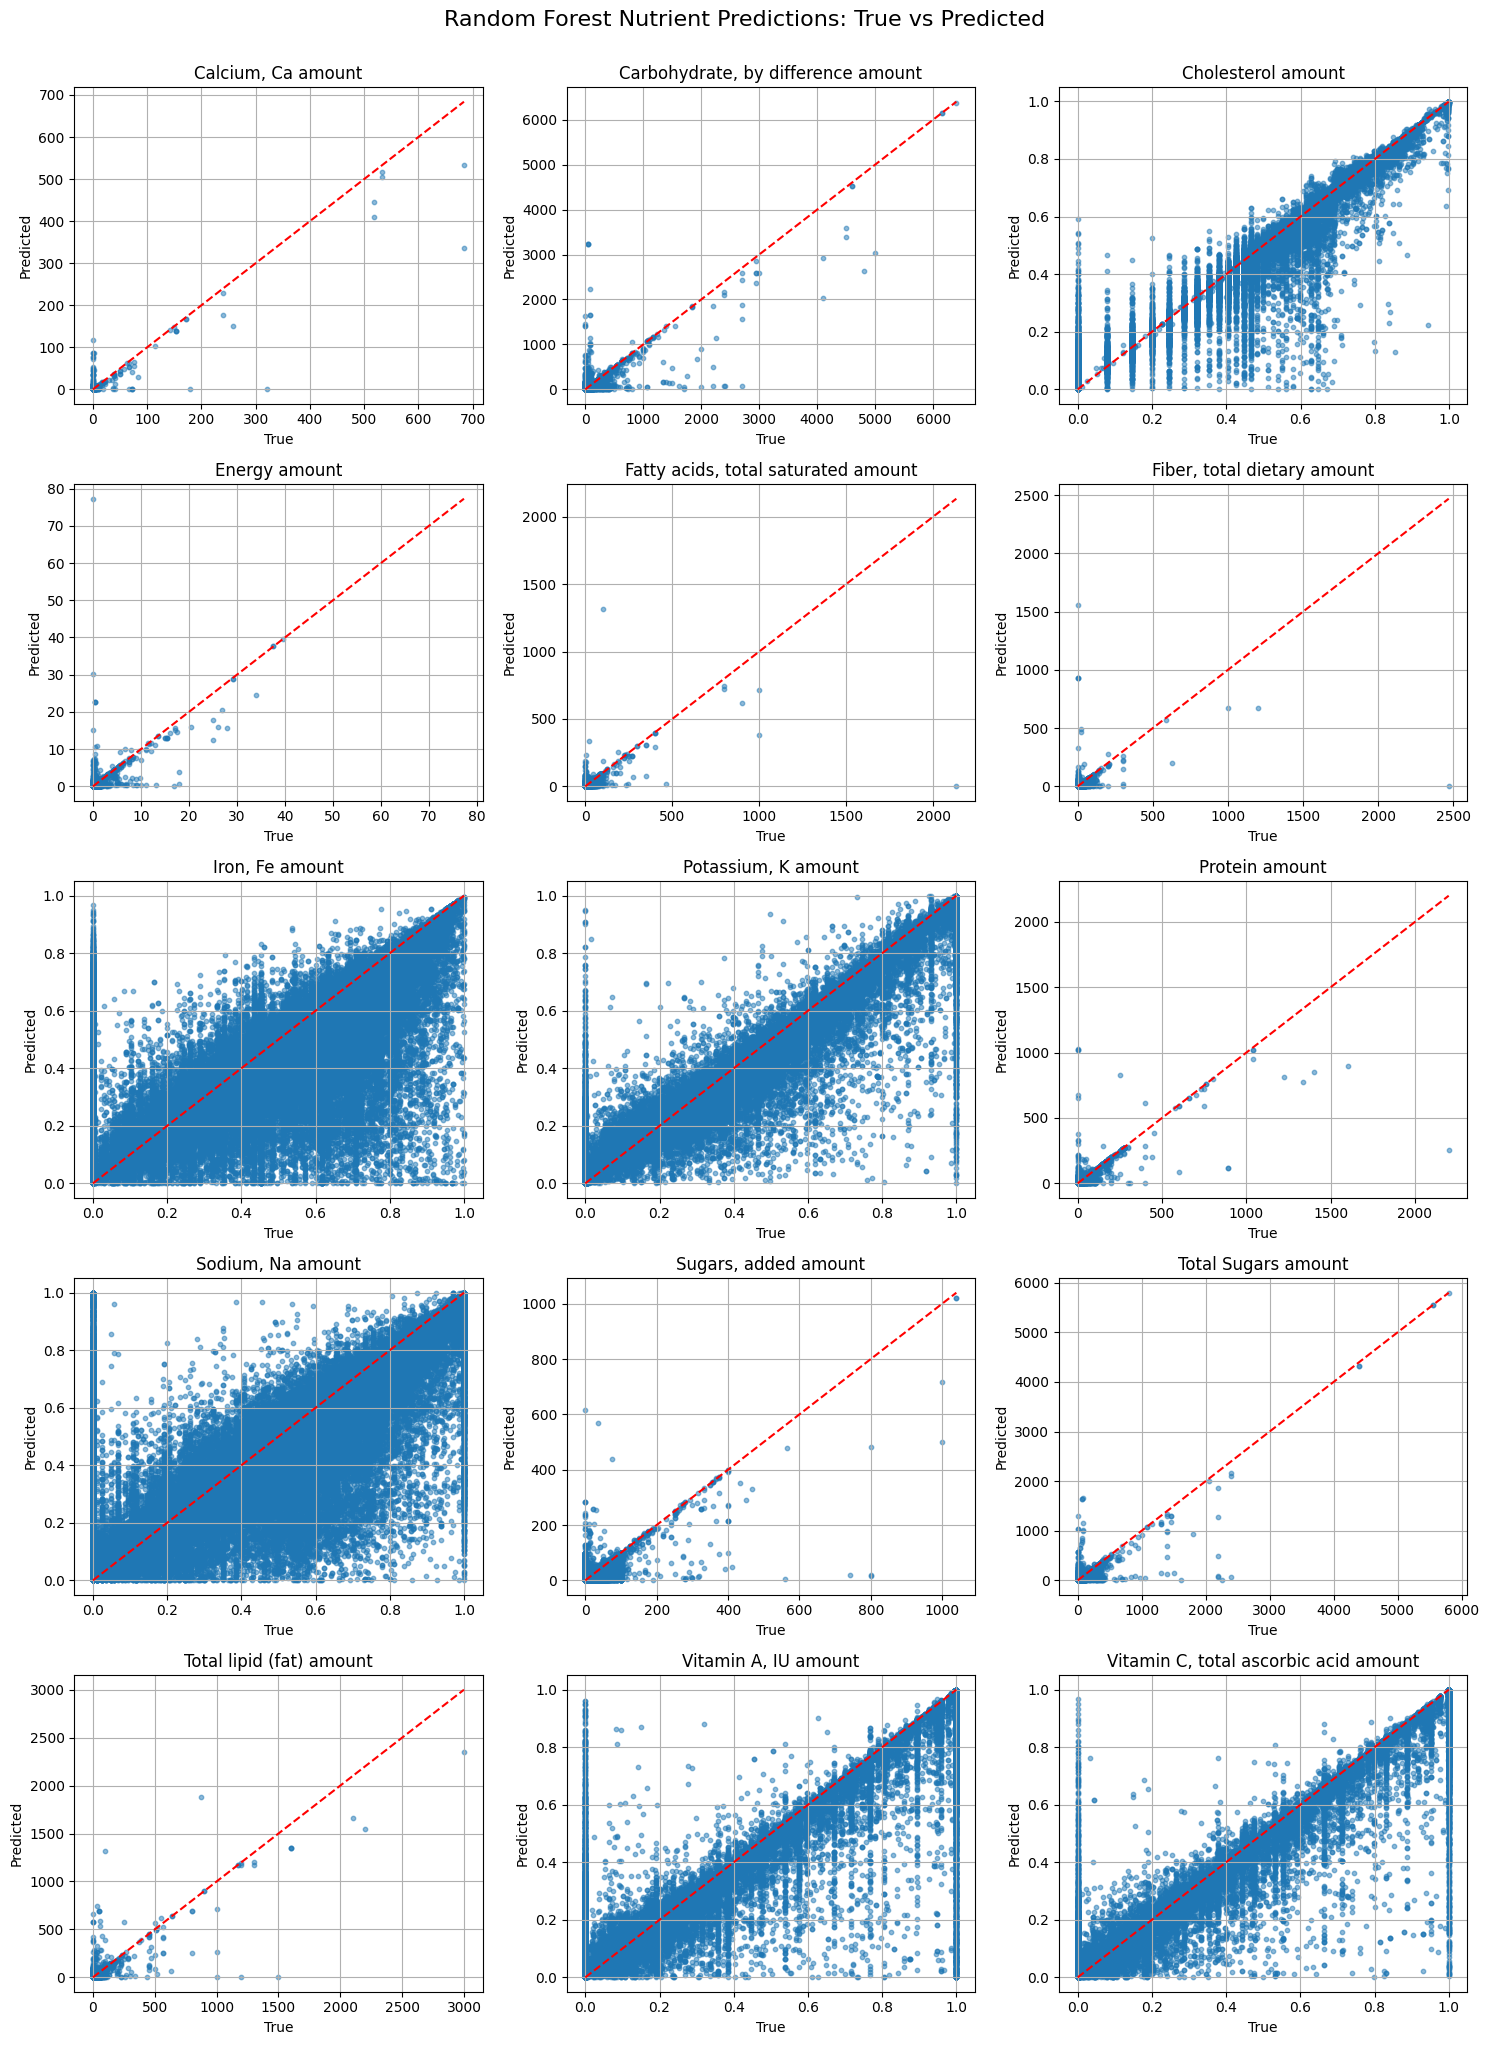

In [10]:
# Visualize Random Forest predictions: scatter plots for each nutrient
num_nutrients = len(nutrient_cols)
cols = 3
rows = int(np.ceil(num_nutrients / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(nutrient_cols):
    ax = axes[i]
    ax.scatter(y_test[:, i], y_pred_rf[:, i], alpha=0.5, s=10)
    min_val = min(np.min(y_test[:, i]), np.min(y_pred_rf[:, i]))
    max_val = max(np.max(y_test[:, i]), np.max(y_pred_rf[:, i]))
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_title(col)
    ax.grid(True)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Random Forest Nutrient Predictions: True vs Predicted', y=1.02, fontsize=16)
plt.show()

In [11]:
# --- Ingredient Classification with Random Forest ---
# Prepare ingredient targets
y_ingredients = food_data[ingredient_oh_cols].values

# Train/test split for ingredients (same split as nutrients)
_, _, y_train_ing, y_test_ing = train_test_split(X, y_ingredients, test_size=0.2, random_state=42)

# Fit one-vs-rest Random Forest for each ingredient
rf_ing_models = []
y_pred_ing = np.zeros_like(y_test_ing)
for i in tqdm(range(y_train_ing.shape[1]), desc='Fitting Random Forest Models'):
    rf_ing = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_ing.fit(X_train, y_train_ing[:, i])
    y_pred_ing[:, i] = rf_ing.predict(X_test)
    rf_ing_models.append(rf_ing)

# Evaluate ingredient classification
ingredient_accs = [accuracy_score(y_test_ing[:, i], y_pred_ing[:, i]) for i in range(y_test_ing.shape[1])]
ingredient_precs = [precision_score(y_test_ing[:, i], y_pred_ing[:, i], zero_division=0) for i in range(y_test_ing.shape[1])]
ingredient_recs = [recall_score(y_test_ing[:, i], y_pred_ing[:, i], zero_division=0) for i in range(y_test_ing.shape[1])]
ingredient_f1s = [f1_score(y_test_ing[:, i], y_pred_ing[:, i], zero_division=0) for i in range(y_test_ing.shape[1])]

Fitting Random Forest Models: 100%|██████████| 8/8 [32:15<00:00, 241.96s/it]


In [12]:
print('Random Forest Ingredient Classification Accuracy:')
for col, acc in zip(ingredient_oh_cols[:10], ingredient_accs[:10]):
    print(f'Accuracy for {col}: {acc:.4f}')

print('\nRandom Forest Ingredient Classification Precision:')
for col, prec in zip(ingredient_oh_cols[:10], ingredient_precs[:10]):
    print(f'Precision for {col}: {prec:.4f}')

print('\nRandom Forest Ingredient Classification Recall:')
for col, rec in zip(ingredient_oh_cols[:10], ingredient_recs[:10]):
    print(f'Recall for {col}: {rec:.4f}')

print('\nRandom Forest Ingredient Classification F1 Score:')
for col, f1 in zip(ingredient_oh_cols[:10], ingredient_f1s[:10]):
    print(f'F1 Score for {col}: {f1:.4f}')

Random Forest Ingredient Classification Accuracy:
Accuracy for ingredient_oh_salt: 0.9999
Accuracy for ingredient_oh_sugar: 0.9999
Accuracy for ingredient_oh_water: 0.9999
Accuracy for ingredient_oh_citricAcid: 0.9871
Accuracy for ingredient_oh_cornSyrup: 0.9952
Accuracy for ingredient_oh_naturalFlavor: 0.9889
Accuracy for ingredient_oh_soyLecithin: 0.9958
Accuracy for ingredient_oh_seaSalt: 0.9886

Random Forest Ingredient Classification Precision:
Precision for ingredient_oh_salt: 0.9998
Precision for ingredient_oh_sugar: 0.9999
Precision for ingredient_oh_water: 0.9999
Precision for ingredient_oh_citricAcid: 0.9778
Precision for ingredient_oh_cornSyrup: 0.9888
Precision for ingredient_oh_naturalFlavor: 0.9788
Precision for ingredient_oh_soyLecithin: 0.9892
Precision for ingredient_oh_seaSalt: 0.9665

Random Forest Ingredient Classification Recall:
Recall for ingredient_oh_salt: 1.0000
Recall for ingredient_oh_sugar: 0.9998
Recall for ingredient_oh_water: 0.9997
Recall for ingredient

In [13]:
print(f'\nMean Ingredient Accuracy: {np.mean(ingredient_accs):.4f}')
print(f'Mean Ingredient Precision: {np.mean(ingredient_precs):.4f}')
print(f'Mean Ingredient Recall: {np.mean(ingredient_recs):.4f}')
print(f'Mean Ingredient F1 Score: {np.mean(ingredient_f1s):.4f}')


Mean Ingredient Accuracy: 0.9944
Mean Ingredient Precision: 0.9876
Mean Ingredient Recall: 0.9684
Mean Ingredient F1 Score: 0.9778
